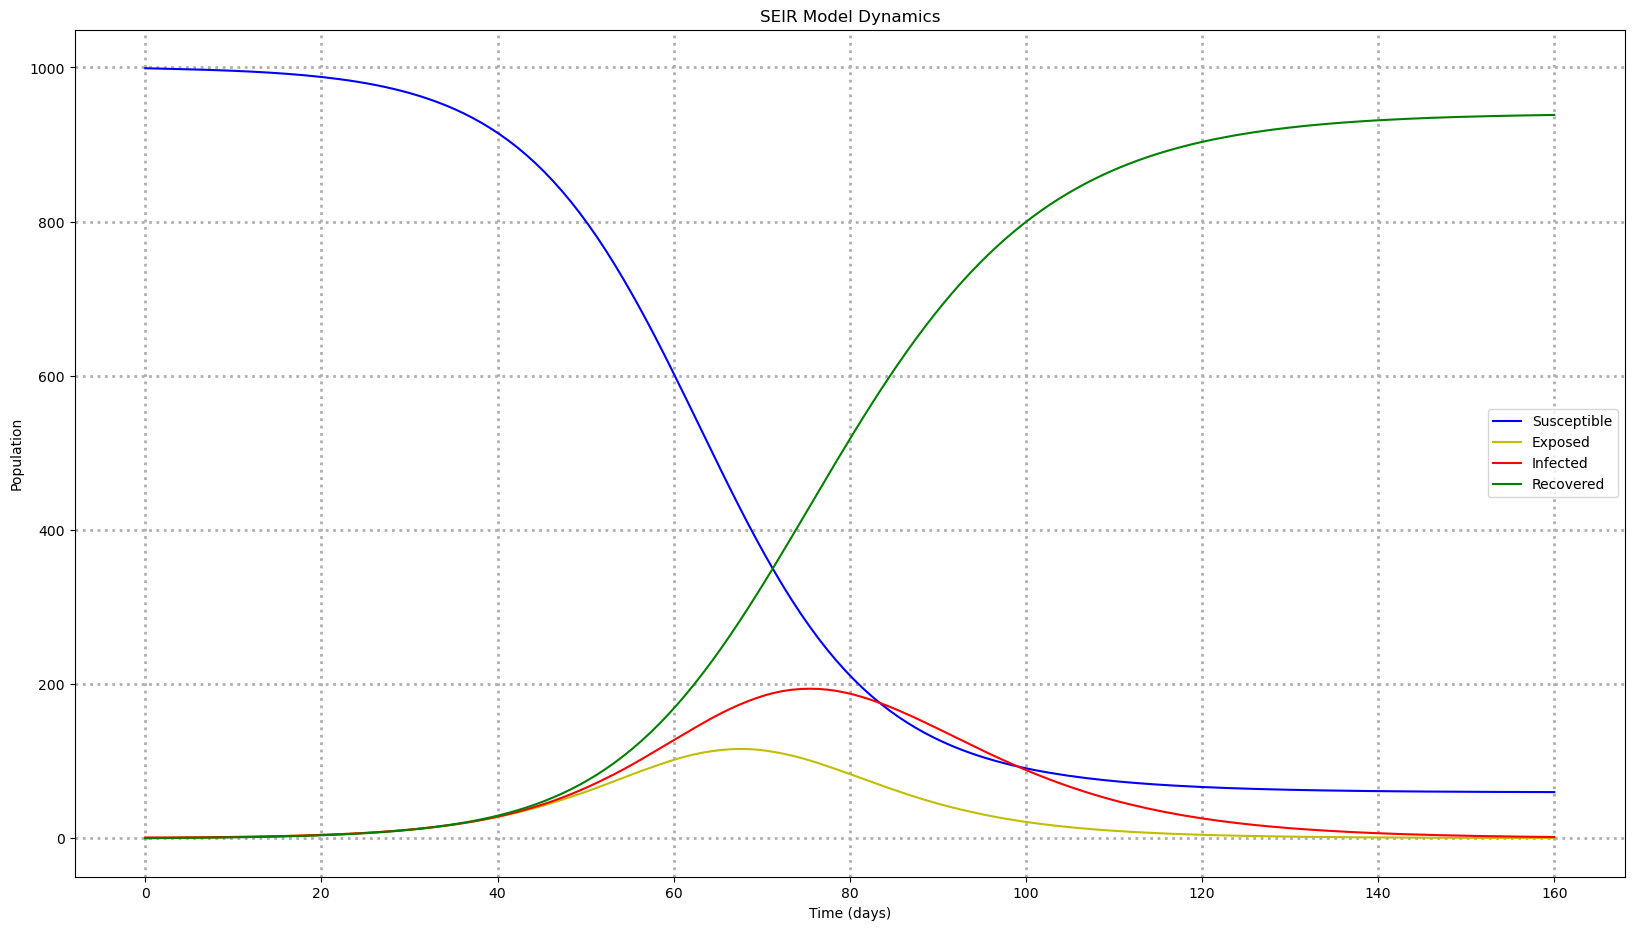

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# theotal population we are modeling -  N
N = 1000
# the initial number of infected and recovered individuals in our data
I0, R0 = 1, 0
# the initial number of exposed individuals in our data
E0 = 0
# everyone else, S0, is susceptible to infection initially
S0 = N - I0 - R0 - E0
# the contact rate, beta, incubation rate, sigma, and mean recovery rate, gamma
beta, sigma, gamma = 0.3, 1/5.2, 1/10
# the time points (days) over which we want to predict using our model
t = np.linspace(0, 160, 160)

# the SEIR model differential equations
def deriv(t, y, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# here we set the initial conditions vector
y0 = S0, E0, I0, R0
# and use scipy to solve the system of differential equations
sol = solve_ivp(deriv, [0, 160], y0, args=(N, beta, sigma, gamma), t_eval=t)

# extract the results
S, E, I, R = sol.y

# plot the data on four separate curves for S(t), E(t), I(t) and R(t)
plt.figure(figsize=(20,11))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, E, 'y', label='Exposed')
plt.plot(t, I, 'r', label='Infected')
plt.plot(t, R, 'g', label='Recovered')
plt.title("SEIR Model Dynamics")
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.legend()
plt.grid(lw=2,ls=":")
plt.show()

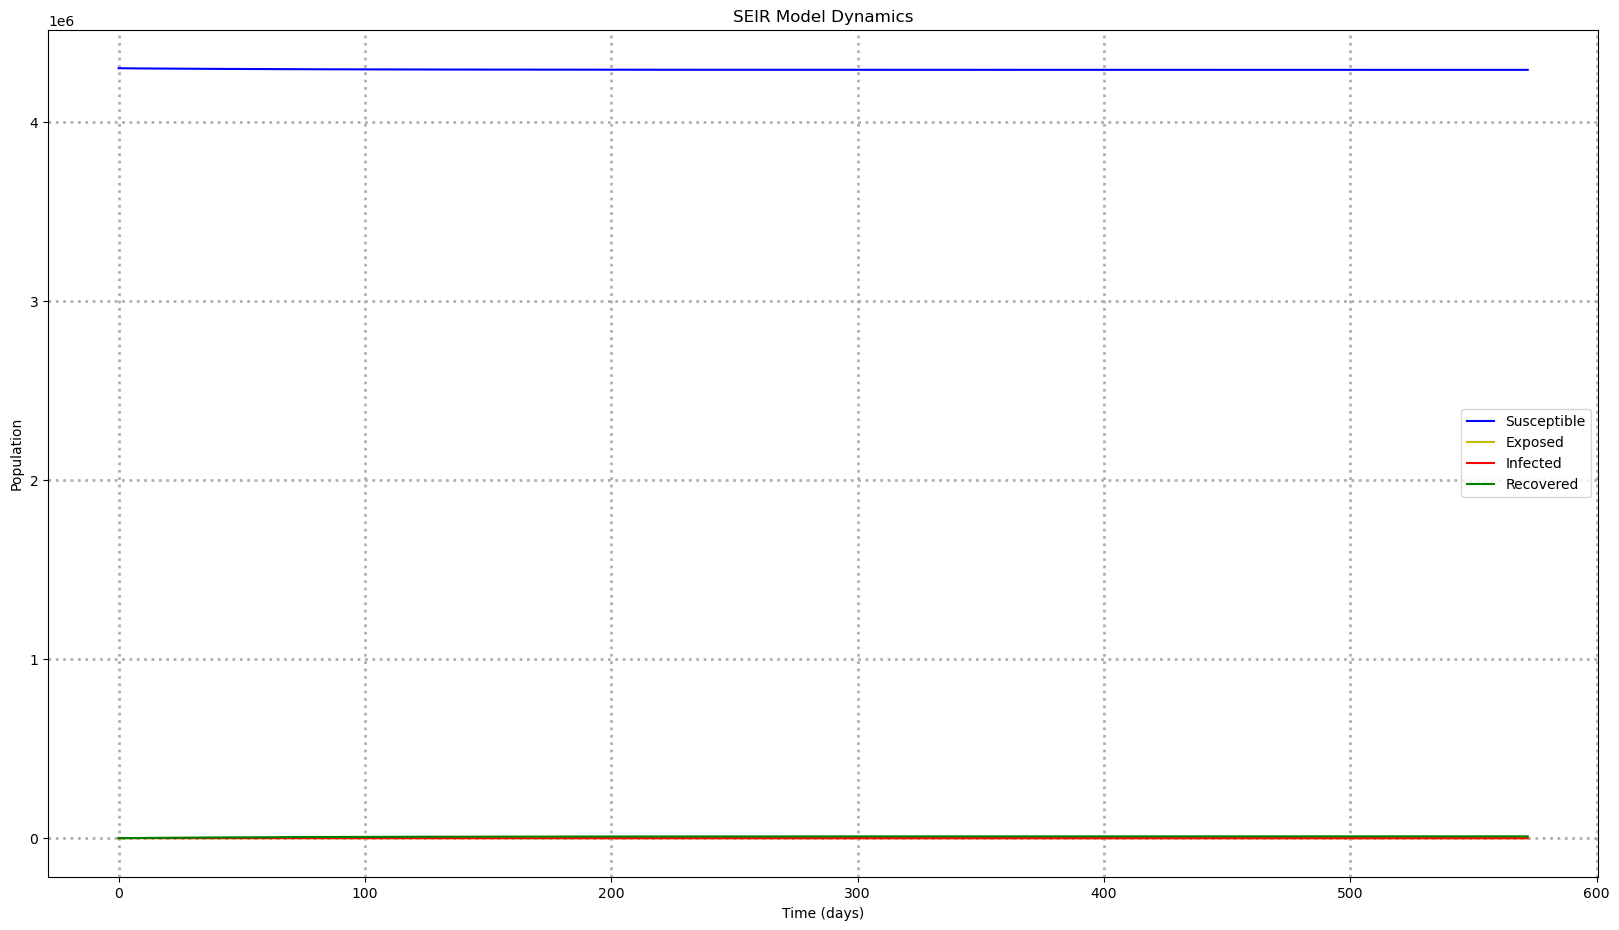

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# theotal population we are modeling -  N
N = 4.3e6
# the initial number of infected and recovered individuals in our data
I0, R0 = 1378, 0
# the initial number of exposed individuals in our data
E0 = 0
# everyone else, S0, is susceptible to infection initially
S0 = N - I0 - R0 - E0
# the contact rate, beta, incubation rate, sigma, and mean recovery rate, gamma
beta, sigma, gamma = 0.164, 1/5.61, 1/5.3
# the time points (days) over which we want to predict using our model
t = np.linspace(0, 572, 572)

# the SEIR model differential equations
def deriv(t, y, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# here we set the initial conditions vector
y0 = S0, E0, I0, R0
# and use scipy to solve the system of differential equations
sol = solve_ivp(deriv, [0, 572], y0, args=(N, beta, sigma, gamma), t_eval=t)

# extract the results
S, E, I, R = sol.y

# plot the data on four separate curves for S(t), E(t), I(t) and R(t)
plt.figure(figsize=(20,11))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, E, 'y', label='Exposed')
plt.plot(t, I, 'r', label='Infected')
plt.plot(t, R, 'g', label='Recovered')
plt.title("SEIR Model Dynamics")
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.legend()
plt.grid(lw=2,ls=":")
plt.show()

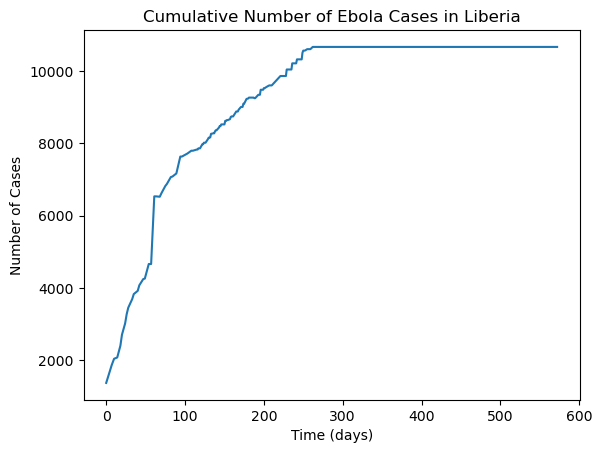

In [182]:
import pandas as pd

# GET THE DATA CLEANED

# import data
df = pd.read_csv("ebola_2014_2016_clean.csv")

# filter data for only Liberia
df_liberia = df[df["Country"] == "Liberia"]

# get just one date per day and take the max reported value
df_liberia = (df_liberia
    .groupby("Date")["Cumulative no. of confirmed, probable and suspected cases"]
    .max()
    .reset_index()
)

#covert the "Date" column to datetime format
df_liberia["Date"] = pd.to_datetime(df_liberia["Date"])

# add column t to represent time in days since the first case was reported
df_liberia["t"] = (df_liberia["Date"] - df_liberia["Date"].min()).dt.days


# PLOT THE DATA

# create a line plot of the cumulative number of cases over time
plt.plot(df_liberia["t"], df_liberia["Cumulative no. of confirmed, probable and suspected cases"])
plt.title("Cumulative Number of Ebola Cases in Liberia")
plt.xlabel("Time (days)")
plt.ylabel("Number of Cases")
plt.show()


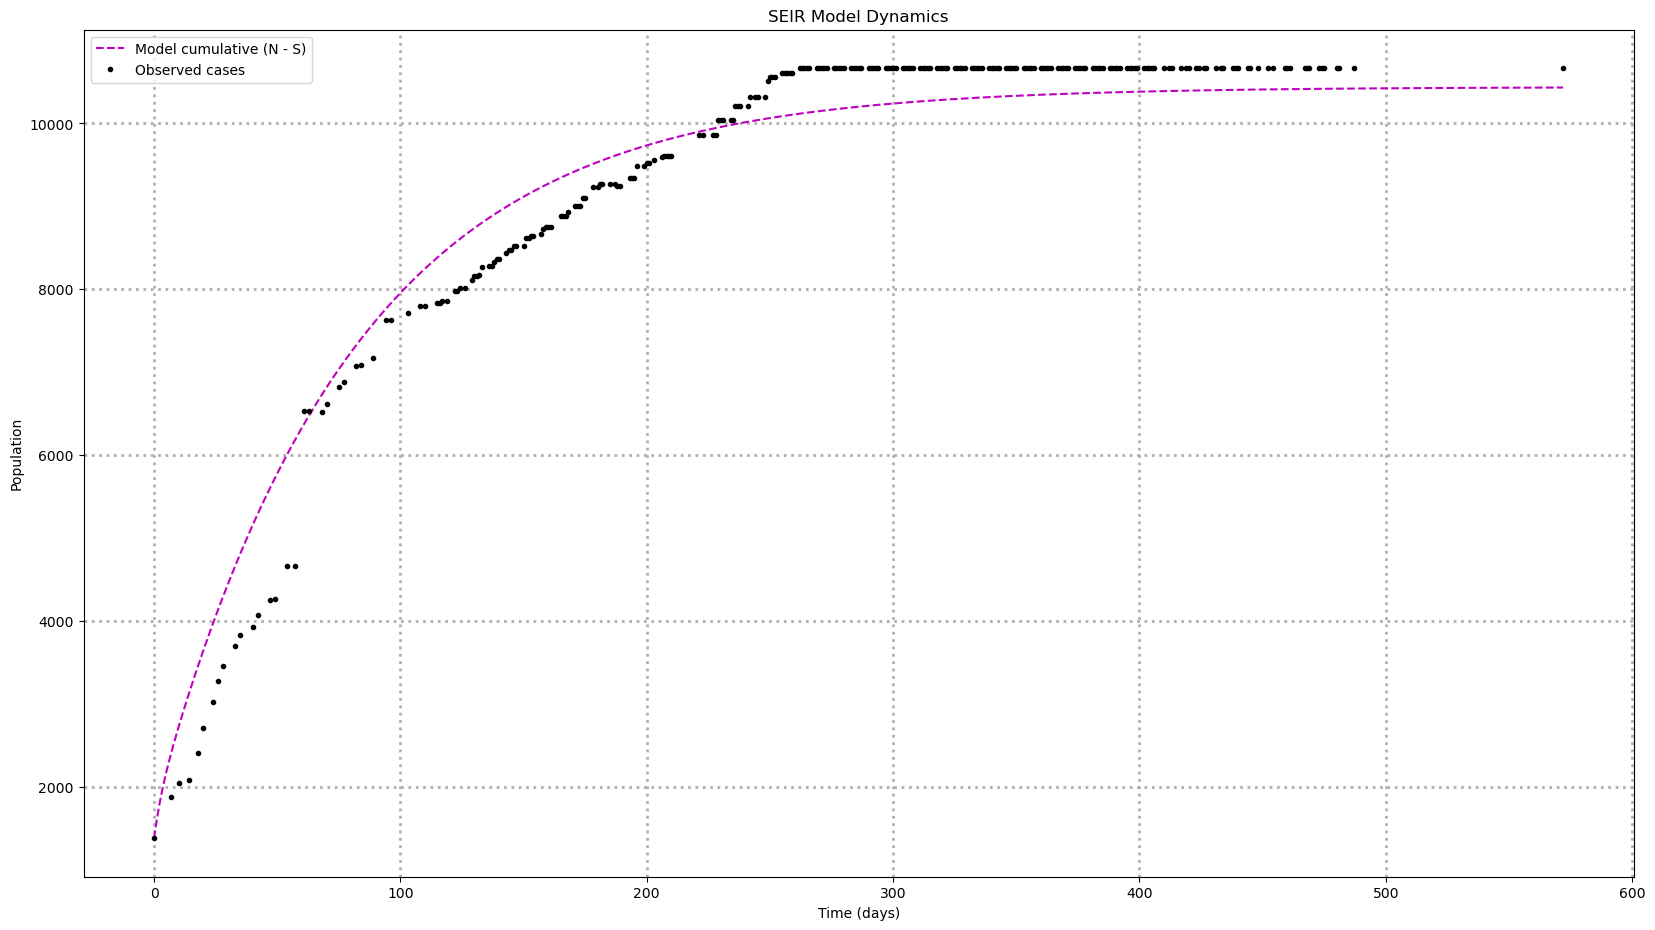

In [183]:
# plot the data on four separate curves for S(t), E(t), I(t) and R(t)
plt.figure(figsize=(20,11))
plt.plot(t, N - S, 'm--', label='Model cumulative (N - S)')
plt.plot(df_liberia["t"], df_liberia["Cumulative no. of confirmed, probable and suspected cases"], 'ko', markersize=3, label='Observed cases')
plt.title("SEIR Model Dynamics")
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.legend()
plt.grid(lw=2,ls=":")
plt.show()